# NSE Next-Day Price Predictor

## 1. Business Understanding

### 1.1 Problem Statement

Retail investors on the NSE often face information asymmetry, high volatility, and liquidity challenges when deciding at what price to place buy (bid) or sell (offer) orders. Many rely on gut feel, broker advice, or simple charts, leading to suboptimal entries/exits, slippage, missed opportunities, or unnecessary losses.
The system aims to reduce this gap by using historical daily data (2022–2025) to forecast near-term price behavior (e.g., next-day close, Day Low, or Day High). This helps investors set smarter limit orders, for example, bidding near a predicted Day Low or offering near a predicted Day High, while incorporating volume and market context.


### 1.2 Stakeholders and Use Case

**Primary stakeholder:** Retail investors using NSE trading platforms (e.g. Safaricom's Ziidi Trader, CBA Loop).  
**Secondary stakeholders:** Licensed NSE stockbrokers who advise clients on daily entry and exit prices.

A retail investor holding EQTY can open this system before market hours, see a predicted next-day closing price, and confidently place a limit buy order near that level without guessing.


### 1.3 Project Objective

Develop a transparent, backtestable short-horizon price prediction system that forecasts next-day Day Low, Day High, and Day Price using 2022–2025 daily data. The system will help investors set smarter limit orders for example, Bid near predicted Day Low or Offer near predicted Day High while factoring in liquidity and market context.

**Business Questions:**
1. What are the key drivers of daily price movements for high-liquidity NSE stocks?
2. How accurately can we forecast the next-day Day Low, Day High, and Day Price to support better bid/offer decisions?
3. Which stocks or segments offer the best trade-off between predictability and liquidity for retail investors?


## 2. Data Understanding

### 2.1 Data Source

Daily OHLCV (Open, High, Low, Close, Volume) data sourced from NSE official daily market reports, covering January 2022 to October 2025. Raw dataset: 67,313 rows across 79 stocks.

### 2.2 Why This Data Is Suitable

Each row represents one stock's full trading activity for one day(price, volume, and range). This mirrors exactly what a retail investor sees when making a limit order decision. The 4-year window covers two full market cycles (2022 downturn, 2024 recovery), giving the model diverse market conditions to learn from.

### 2.3 Feature Descriptions

| Column | Description |
|--------|-------------|
| day_price | Closing price for the day (KES) |
| day_low / day_high | Intraday price range |
| previous | Previous day's closing price |
| volume | Shares traded |
| 12m_low / 12m_high | 52-week price range |
| changepct | Daily percentage change |

### 2.4 Data Limitations

- **29.9% zero-volume days** across all stocks - many NSE stocks trade infrequently. We address this by restricting to 10 blue-chip stocks.
- **Structural price breaks in 2025** -KPLC rose from KES 2.36 to KES 9.31 due to regulatory changes. No price-history model can predict these events.
- **No alternative data** - earnings announcements, dividends, and macroeconomic indicators are not included, which limits predictability of unusual market moves.

### 2.5 Import Libraries

In [195]:
import pandas as pd
import numpy as np
import glob
import os

### 2.6 Loading All Files
We load all four yearly CSV files from the data folder and combine them into a single dataframe.

In [196]:
folder_path = "nse-2022-2025-data"

all_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

dfs = []

for file in all_files:
    file_path = os.path.join(folder_path, file)
    df = pd.read_csv(file_path)
    
    df['source_file'] = file  
    dfs.append(df)

# Combine all into one dataset
nse_data = pd.concat(dfs, ignore_index=True)

print("Total rows:", nse_data.shape[0])
print("Total columns:", nse_data.shape[1])

Total rows: 67313
Total columns: 14


In [197]:
print("\nFirst 5 rows of combined data:")
print(df.head())


First 5 rows of combined data:
       Date  Code                     Name  12m Low  12m High  Day Low  \
0  2-Jan-25  EGAD              Eaagads Ltd     10.8     24.10     12.0   
1  2-Jan-25  KUKZ               Kakuzi Plc    365.0    440.00    385.0   
2  2-Jan-25  KAPC  Kapchorua Tea Kenya Plc    198.0    424.25    236.0   
3  2-Jan-25  LIMT           Limuru Tea Plc    295.0    423.50    350.0   
4  2-Jan-25  SASN               Sasini Plc     13.3     20.40     14.8   

   Day High  Day Price Previous Change Change% Volume Adjusted Price  \
0      12.0      12.00       12      -       -      -              -   
1     400.0     392.50      385    7.5   1.95%    200              -   
2     240.0     239.25      235   4.25   1.81%   1000              -   
3     350.0     350.00      350      -       -      -              -   
4      15.0      15.00       15      -       -  38700              -   

                    source_file  
0  NSE_data_all_stocks_2025.csv  
1  NSE_data_all_stocks

In [198]:
nse_data.info()
nse_data.describe()
nse_data.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67313 entries, 0 to 67312
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            67313 non-null  object
 1   Code            67313 non-null  object
 2   Name            67313 non-null  object
 3   12m Low         67313 non-null  object
 4   12m High        67313 non-null  object
 5   Day Low         67313 non-null  object
 6   Day High        67313 non-null  object
 7   Day Price       67313 non-null  object
 8   Previous        67313 non-null  object
 9   Change          67313 non-null  object
 10  Change%         67313 non-null  object
 11  Volume          67313 non-null  object
 12  Adjusted Price  67313 non-null  object
 13  source_file     67313 non-null  object
dtypes: object(14)
memory usage: 7.2+ MB


Index(['Date', 'Code', 'Name', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume',
       'Adjusted Price', 'source_file'],
      dtype='object')

In [199]:
print("\nDataset info:")
df.info()

print("\nData types:")
print(df.dtypes)


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15114 entries, 0 to 15113
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            15114 non-null  object 
 1   Code            15114 non-null  object 
 2   Name            15114 non-null  object 
 3   12m Low         15114 non-null  float64
 4   12m High        15114 non-null  float64
 5   Day Low         15114 non-null  float64
 6   Day High        15114 non-null  float64
 7   Day Price       15114 non-null  float64
 8   Previous        15114 non-null  object 
 9   Change          15114 non-null  object 
 10  Change%         15114 non-null  object 
 11  Volume          15114 non-null  object 
 12  Adjusted Price  15114 non-null  object 
 13  source_file     15114 non-null  object 
dtypes: float64(5), object(9)
memory usage: 1.6+ MB

Data types:
Date               object
Code               object
Name               object
12m Low      

## 3. Data Preparation

### 3.1 Standardise Column Names

Column names come in inconsistent formats across the four yearly files; mixed case, spaces, special characters. We standardise to snake_case so all downstream code references columns consistently.

In [200]:
def standardize_columns(df):
    """
    Rename columns to clean snake_case:
      - Strip leading/trailing whitespace
      - Lowercase everything
      - Replace spaces with underscores
      - Replace '%' with 'pct'
      - Replace special chars like '/' with '_'
    """
    df = df.copy()
    df.columns = (
        df.columns
          .str.strip()
          .str.lower()
          .str.replace(' ', '_', regex=False)
          .str.replace('%', 'pct', regex=False)
          .str.replace('/', '_', regex=False)
    )
    return df

nse_data = standardize_columns(nse_data)

print("Standardised column names:")
print(nse_data.columns.tolist())

Standardised column names:
['date', 'code', 'name', '12m_low', '12m_high', 'day_low', 'day_high', 'day_price', 'previous', 'change', 'changepct', 'volume', 'adjusted_price', 'source_file']


### 3.2 Convert Data Types and Clean Values

Raw CSVs store prices as text with dashes, commas, and percentage symbols. We convert all price and volume columns to numeric. Dashes represent missing values and are treated as NaN.

In [201]:
# Columns that must be numeric 
numeric_cols = ['12m_low', '12m_high', 'day_low', 'day_high', 'day_price', 'previous']

for col in numeric_cols:
    nse_data[col] = pd.to_numeric(nse_data[col], errors='coerce')

# Clean Volume: remove commas, replace '-' with NaN
nse_data['volume'] = (
    nse_data['volume']
    .astype(str)
    .str.replace(',', '', regex=False)
    .replace('-', np.nan)
)
nse_data['volume'] = pd.to_numeric(nse_data['volume'], errors='coerce')

# Clean Change: '-' means no change to 0
nse_data['change'] = pd.to_numeric(
    nse_data['change'].astype(str).replace('-', '0'), errors='coerce'
).fillna(0)

# Clean Change%: strip '%', '-' to 0
nse_data['changepct'] = pd.to_numeric(
    nse_data['changepct'].astype(str)
                         .str.replace('%', '', regex=False)
                         .replace('-', '0'),
    errors='coerce'
).fillna(0)

# Parse dates
nse_data['date'] = pd.to_datetime(nse_data['date'], dayfirst=True, errors='coerce')

# Sort by stock then date
nse_data = nse_data.sort_values(['code', 'date']).reset_index(drop=True)

print("Dtypes after cleaning:")
print(nse_data.dtypes)
print(f"\nDate range: {nse_data['date'].min().date()} → {nse_data['date'].max().date()}")
print(f"Null counts:\n{nse_data.isnull().sum()}")

Dtypes after cleaning:
date              datetime64[ns]
code                      object
name                      object
12m_low                  float64
12m_high                 float64
day_low                  float64
day_high                 float64
day_price                float64
previous                 float64
change                   float64
changepct                float64
volume                   float64
adjusted_price            object
source_file               object
dtype: object

Date range: 2022-01-03 → 2025-10-31
Null counts:
date                  0
code                  0
name                  0
12m_low            3185
12m_high           4517
day_low            4235
day_high           4235
day_price          4203
previous           4203
change                0
changepct             0
volume            23043
adjusted_price        0
source_file           0
dtype: int64


### 3.3 Drop Irrelevant Column

`adjusted_price` is almost entirely dashes (missing) and has no modelling value. We remove it.

In [202]:
# Drop adjusted_price column — mostly '-', not useful for modelling
nse_data = nse_data.drop(columns=['adjusted_price'])

print("adjusted_price removed.")
print("Remaining columns:", nse_data.columns.tolist())
print("Shape:", nse_data.shape)

adjusted_price removed.
Remaining columns: ['date', 'code', 'name', '12m_low', '12m_high', 'day_low', 'day_high', 'day_price', 'previous', 'change', 'changepct', 'volume', 'source_file']
Shape: (67313, 13)


### 3.4 Drop Rows with Missing Core Prices

Rows where day_low, day_high, day_price, or previous are missing cannot be used for modelling or as targets. We drop them entirely

In [203]:
# Drop rows where core price columns are missing
before = len(nse_data)
nse_data = nse_data.dropna(subset=['day_low', 'day_high', 'day_price', 'previous'])
after = len(nse_data)

print(f"Rows dropped: {before - after:,}")
print(f"Rows remaining: {after:,}")

Rows dropped: 4,244
Rows remaining: 63,069


### 3.5 Fill 52-Week High/Low

The 52-week high and low are updated periodically, not daily. Forward-fill carries the last known value forward; backward-fill handles missing values at the start of a stock's history.

In [204]:
# Forward-fill first (carry last known value forward) 
nse_data['12m_low']  = nse_data.groupby('code')['12m_low'].ffill()
nse_data['12m_high'] = nse_data.groupby('code')['12m_high'].ffill()

# Backward-fill to catch nulls at the very start of a stock's history 
nse_data['12m_low']  = nse_data.groupby('code')['12m_low'].bfill()
nse_data['12m_high'] = nse_data.groupby('code')['12m_high'].bfill()

print("Nulls after forward + backward fill:")
print(nse_data[['12m_low', '12m_high']].isnull().sum())

Nulls after forward + backward fill:
12m_low     0
12m_high    0
dtype: int64


### 3.6 Fill Missing Volume with Zero

No volume recorded means no trades occurred that day (this is a valid market state, not missing data). We fill with zero rather than dropping these rows.

In [205]:
nse_data['volume'] = nse_data['volume'].fillna(0)

print("Volume nulls remaining:", nse_data['volume'].isnull().sum())

Volume nulls remaining: 0


### 3.7 Remove Source File Column

The `source_file` column was used to track which yearly CSV each row came from during loading. It has no analytical value and is removed.

In [206]:
nse_data = nse_data.drop(columns=['source_file'])

print("Remaining columns:", nse_data.columns.tolist())

Remaining columns: ['date', 'code', 'name', '12m_low', '12m_high', 'day_low', 'day_high', 'day_price', 'previous', 'change', 'changepct', 'volume']


### 3.8 Remove Duplicate Rows

Each stock should have exactly one row per trading day. Duplicate (code, date) pairs would inflate training data and bias the model.

In [207]:
dupes = nse_data.duplicated(subset=['code', 'date']).sum()
print(f"Duplicate (code + date) rows: {dupes}")

if dupes > 0:
    nse_data = nse_data.drop_duplicates(subset=['code', 'date'])
    print(f" Duplicates removed. Rows remaining: {len(nse_data):,}")
else:
    print(" No duplicates found.")

Duplicate (code + date) rows: 0
 No duplicates found.


### 3.9 Validate Price Logic

A stock's closing price must fall between its daily low and high. Rows where this is violated are data errors in the source, therefore keeping them would teach the model incorrect price relationships.

In [208]:
invalid = nse_data[
    (nse_data['day_low'] > nse_data['day_high']) |
    (nse_data['day_price'] < nse_data['day_low']) |
    (nse_data['day_price'] > nse_data['day_high'])
]

print(f"Invalid price rows: {len(invalid)}")
if len(invalid) > 0:
    print(invalid[['code','date','day_low','day_high','day_price']].head(10))
    nse_data = nse_data.drop(index=invalid.index)
    print(f" Invalid rows removed. Rows remaining: {len(nse_data):,}")

Invalid price rows: 10
       code       date  day_low  day_high  day_price
2239   BAMB 2022-07-26    33.00     33.00      33.80
2334   BAMB 2022-12-13    31.50     31.50      31.40
6118   BRIT 2022-12-13     5.10      5.10       5.14
9902    CIC 2022-12-13     1.88      1.88       1.92
10848  COOP 2022-12-13    12.20     12.50      12.10
24209   IMH 2022-12-13    16.95     16.95      16.90
26952   KCB 2022-07-26    40.00     40.00      39.65
41674  NCBA 2022-12-13    31.60     31.60      34.45
43566   NSE 2022-12-13     6.84      6.86       6.82
49980  SCBK 2022-12-13   135.00    135.00     142.25
 Invalid rows removed. Rows remaining: 63,059


### 3.10 Cleaned Dataset Summary

After all preparation steps, the dataset is clean and ready for analysis.

In [209]:

print(f"Shape          : {nse_data.shape}")
print(f"Stocks         : {nse_data['code'].nunique()}")
print(f"Date range     : {nse_data['date'].min().date()} → {nse_data['date'].max().date()}")
print(f"Null values    :\n{nse_data.isnull().sum()}")
print(f"\nDtypes         :\n{nse_data.dtypes}")

Shape          : (63059, 12)
Stocks         : 79
Date range     : 2022-01-03 → 2025-10-31
Null values    :
date         0
code         0
name         0
12m_low      0
12m_high     0
day_low      0
day_high     0
day_price    0
previous     0
change       0
changepct    0
volume       0
dtype: int64

Dtypes         :
date         datetime64[ns]
code                 object
name                 object
12m_low             float64
12m_high            float64
day_low             float64
day_high            float64
day_price           float64
previous            float64
change              float64
changepct           float64
volume              float64
dtype: object


## 4. Exploratory Data Analysis (EDA)

We explore the data to understand its properties before building features or models. Key questions: how are prices distributed, which stocks are most liquid, how volatile are returns, and what correlates with next-day price?

### 4.1 Import Visualisation Libraries

In [210]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


nse_data['year']       = nse_data['date'].dt.year
nse_data['month']      = nse_data['date'].dt.month
nse_data['dow']        = nse_data['date'].dt.day_name()
nse_data['day_range']  = nse_data['day_high'] - nse_data['day_low']
nse_data['log_return'] = nse_data.groupby('code')['day_price'] \
                                  .transform(lambda x: np.log(x / x.shift(1)))

blue_chips = ['EQTY', 'KCB', 'SCOM', 'COOP', 'SCBK', 'ABSA',
              'KNRE', 'KEGN', 'KPLC', 'BRIT']

core_cols = ['date','code','name','12m_low','12m_high','day_low',
             'day_high','day_price','previous','change','changepct','volume']
eda_cols  = ['year','month','dow','day_range','log_return']

print(f'Core columns (cleaned dataset) : {len(core_cols)}')
print(f'EDA helper columns (derived)   : {len(eda_cols)}')
print(f'Dataset shape: {nse_data.shape}')
print(f'Blue chips ({len(blue_chips)})              : {blue_chips}')


Core columns (cleaned dataset) : 12
EDA helper columns (derived)   : 5
Dataset shape: (63059, 17)
Blue chips (10)              : ['EQTY', 'KCB', 'SCOM', 'COOP', 'SCBK', 'ABSA', 'KNRE', 'KEGN', 'KPLC', 'BRIT']


### 4.2 Records per Year and Price Distribution

We check data coverage across years and the overall distribution of closing prices. The large gap between median and mean price signals a right-skewed distribution i.e a small number of expensive stocks (e.g. SCBK at ~KES 294) pull the mean up significantly.

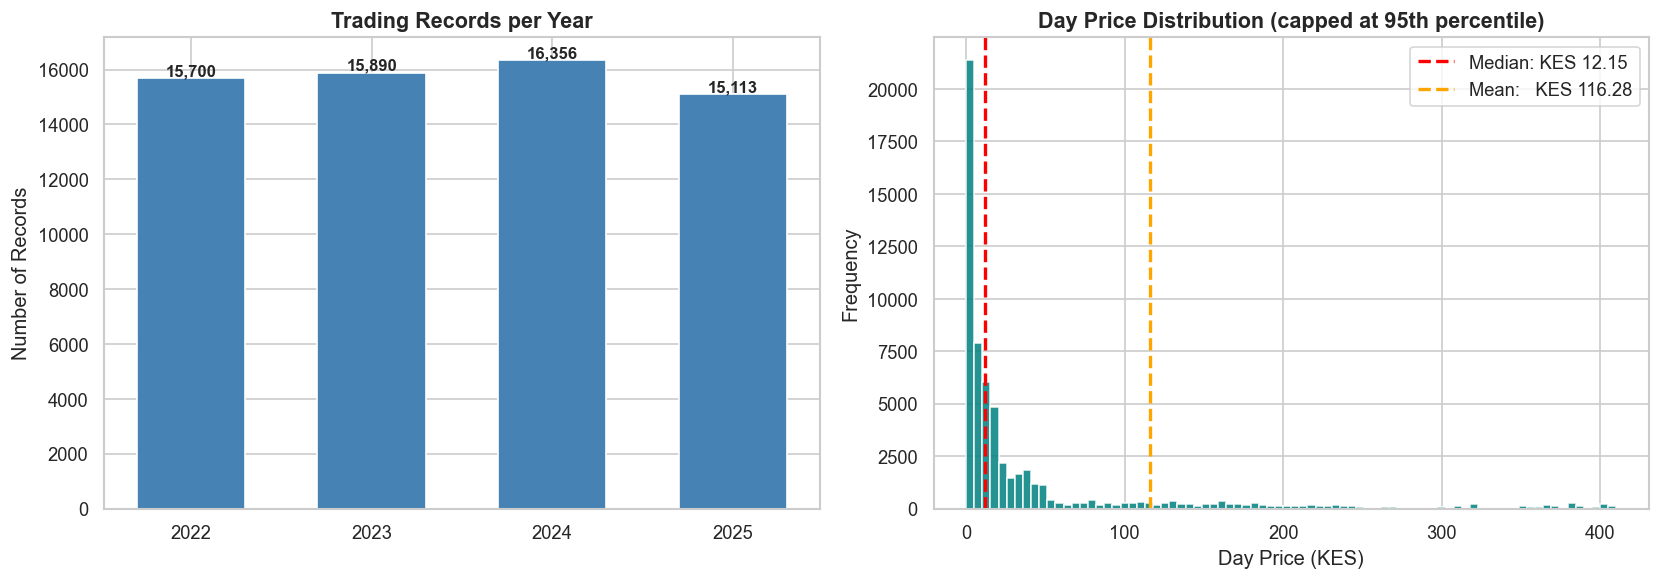

Summary Statistics
       day_price   day_low  day_high        volume  changepct
count   63059.00  63059.00  63059.00  6.305900e+04   63059.00
mean      116.28    115.91    117.00  2.621158e+05       0.44
std       431.47    430.70    436.39  2.110072e+06       4.67
min         0.01      0.01      0.02  0.000000e+00     -96.47
25%         3.70      3.65      3.80  0.000000e+00       0.00
50%        12.15     12.00     12.40  2.300000e+03       0.00
75%        41.65     41.00     42.30  3.300000e+04       0.90
max      5335.00   5100.00   9800.00  2.084859e+08     910.43


In [211]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Records per year 
yr_counts = nse_data.groupby('year').size()
axes[0].bar(yr_counts.index.astype(str), yr_counts.values,
            color='steelblue', edgecolor='white', width=0.6)
axes[0].set_title('Trading Records per Year', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Records')
for i, v in enumerate(yr_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

# Price distribution (capped at 95th percentile to handle outliers) 
prices = nse_data['day_price']
cap    = prices.quantile(0.95)
axes[1].hist(prices[prices <= cap], bins=80, color='teal', edgecolor='white', alpha=0.85)
axes[1].axvline(prices.median(), color='red',    lw=2, linestyle='--',
                label=f'Median: KES {prices.median():.2f}')
axes[1].axvline(prices.mean(),   color='orange', lw=2, linestyle='--',
                label=f'Mean:   KES {prices.mean():.2f}')
axes[1].set_title('Day Price Distribution (capped at 95th percentile)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day Price (KES)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Summary Statistics')
print(nse_data[['day_price','day_low','day_high','volume','changepct']].describe().round(2))

### 4.3 Top 15 Stocks by Average Daily Volume

Liquidity determines which stocks are reliable for retail investors. SCOM (Safaricom) dominates with 7.4M average daily shares, which is more than 3x the next stock. We focus on blue chips since they are consistent and have a high-volume trading.

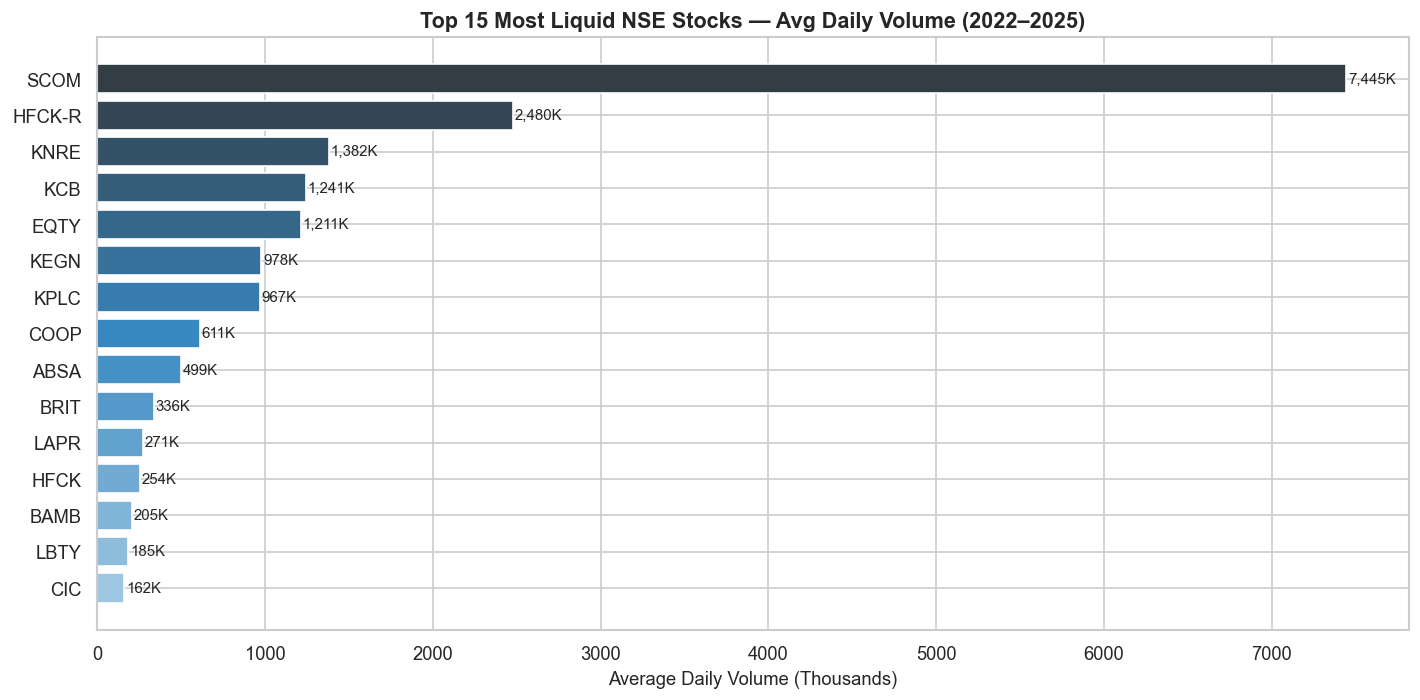


Top 15 Stocks by Avg Daily Volume:
       Avg Daily Volume
code                   
SCOM          7,445,002
HFCK-R        2,479,807
KNRE          1,381,571
KCB           1,241,449
EQTY          1,211,458
KEGN            978,047
KPLC            966,687
COOP            611,365
ABSA            499,242
BRIT            335,582
LAPR            271,351
HFCK            253,649
BAMB            204,653
LBTY            184,833
CIC             161,821


In [212]:
top15_vol = (nse_data.groupby('code')['volume']
             .mean()
             .sort_values(ascending=False)
             .head(15))

fig, ax = plt.subplots(figsize=(12, 6))
colors  = sns.color_palette('Blues_d', 15)
bars    = ax.barh(top15_vol.index[::-1], top15_vol.values[::-1] / 1e3,
                  color=colors, edgecolor='white')
ax.set_xlabel('Average Daily Volume (Thousands)', fontsize=11)
ax.set_title('Top 15 Most Liquid NSE Stocks — Avg Daily Volume (2022–2025)',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, top15_vol.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f'{val/1e3:,.0f}K', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 15 Stocks by Avg Daily Volume:')
print(top15_vol.rename('Avg Daily Volume').apply(lambda x: f'{x:,.0f}').to_frame())

### 4.4 Price Trends for Blue Chip Stocks

We visualise the full price history for each blue chip. The shaded band shows the day price.

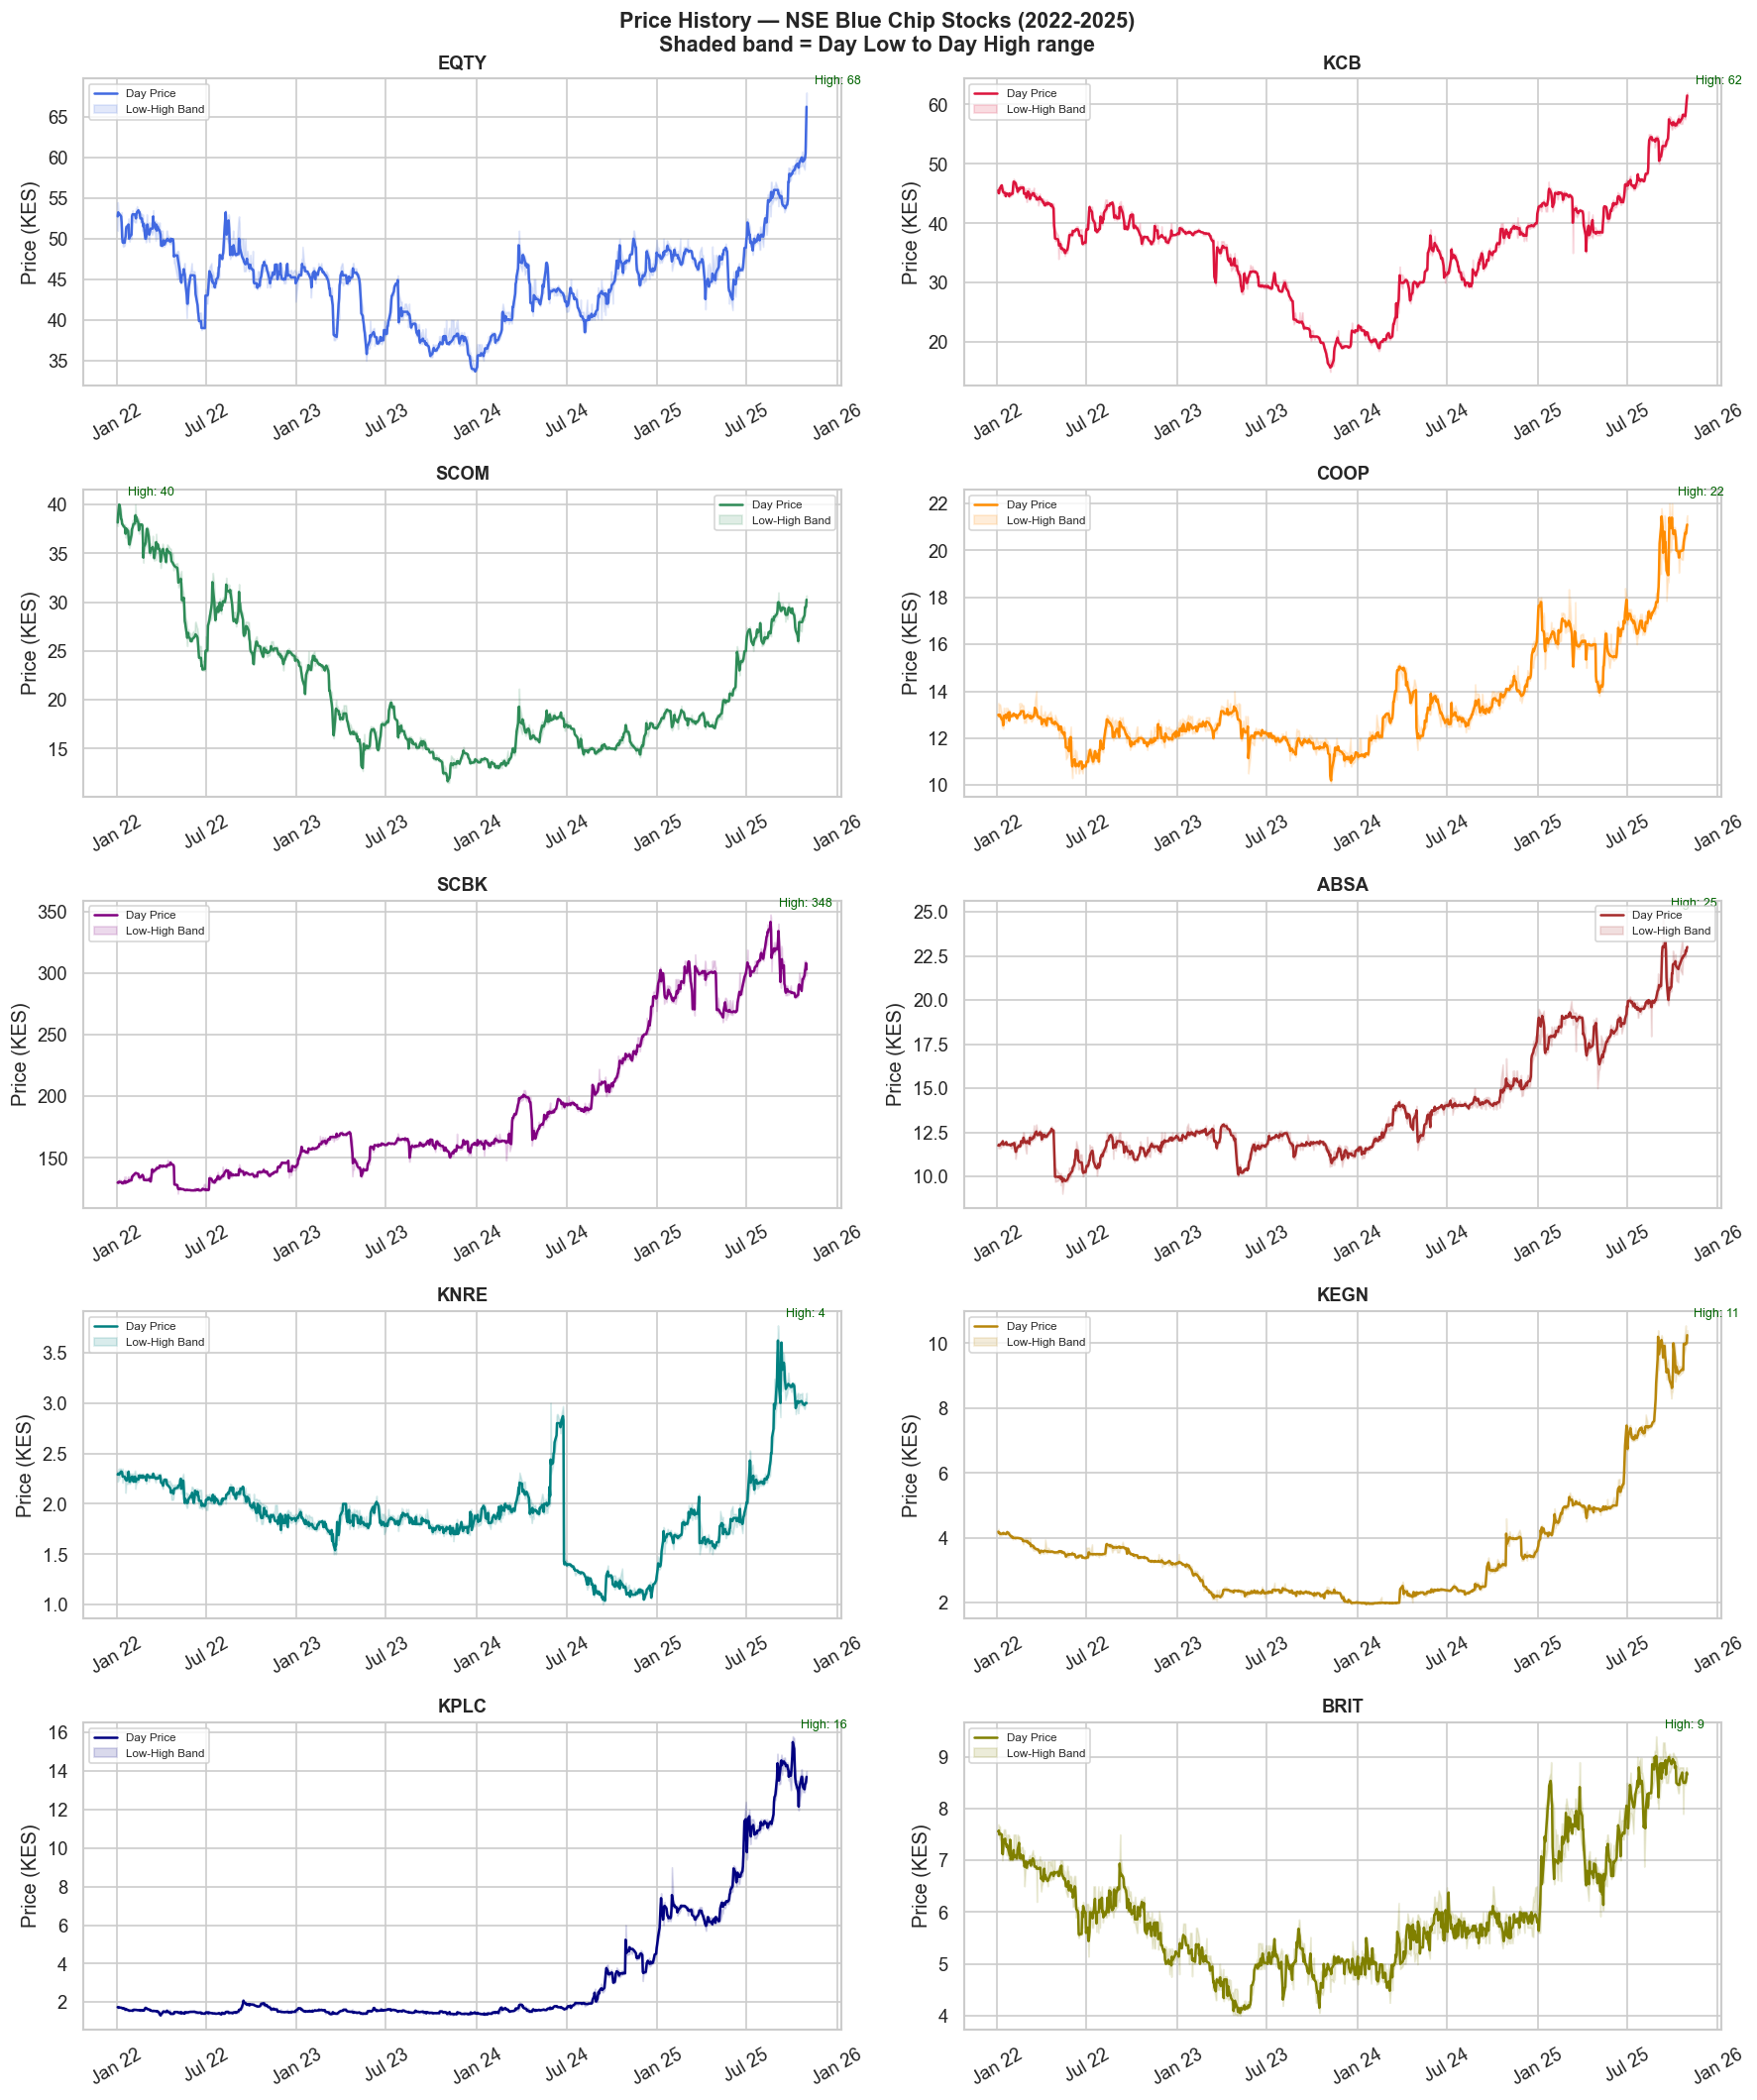

In [213]:
colors_bc = ['royalblue','crimson','seagreen','darkorange',
              'purple','brown','teal','darkgoldenrod','navy','olive']

fig, axes = plt.subplots(5, 2, figsize=(15, 18))
axes      = axes.flatten()

for i, (code, color) in enumerate(zip(blue_chips, colors_bc)):
    sub = nse_data[nse_data['code'] == code]
    if sub.empty:
        axes[i].set_visible(False)
        continue
    axes[i].plot(sub['date'], sub['day_price'], color=color, lw=1.5, label='Day Price')
    axes[i].fill_between(sub['date'], sub['day_low'], sub['day_high'],
                         alpha=0.15, color=color, label='Low-High Band')
    idx_max = sub['day_high'].idxmax()
    axes[i].annotate(
        f"High: {sub.loc[idx_max,'day_high']:.0f}",
        xy=(sub.loc[idx_max, 'date'], sub.loc[idx_max, 'day_high']),
        fontsize=7.5, color='darkgreen',
        xytext=(5, 5), textcoords='offset points'
    )
    axes[i].set_title(f'{code}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Price (KES)')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=7)

fig.suptitle(
    'Price History — NSE Blue Chip Stocks (2022-2025)\n'
    'Shaded band = Day Low to Day High range',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


### 4.5 Top 15 Most Volatile Stocks

Volatility is measured as the standard deviation of daily log returns. All 15 most volatile stocks are small-cap (none of the blue chips appear). Large, heavily traded stocks have tighter bid-ask spreads and more price stability. This confirms that blue chips are the right focus for a retail limit order tool.

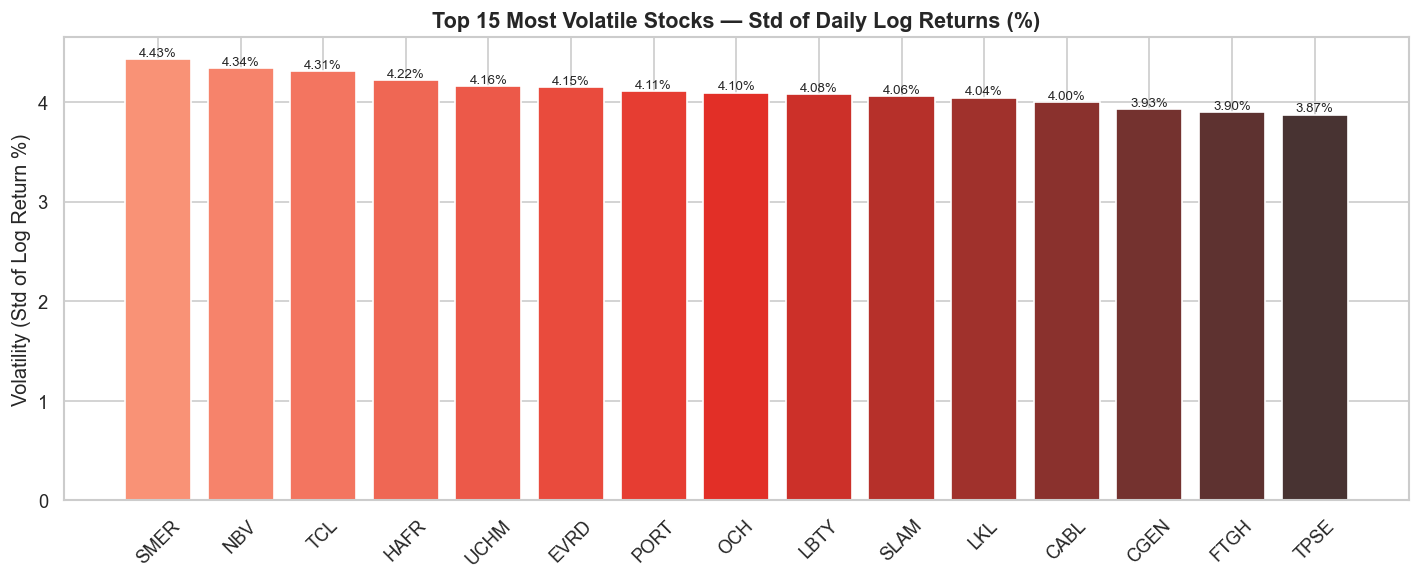

Top 15 Most Volatile Stocks (Daily Log Return Std):
      Volatility %
code              
SMER         4.429
NBV          4.341
TCL          4.310
HAFR         4.217
UCHM         4.159
EVRD         4.152
PORT         4.107
OCH          4.095
LBTY         4.079
SLAM         4.062
LKL          4.045
CABL         4.001
CGEN         3.927
FTGH         3.901
TPSE         3.874


In [214]:
# Exclude HFCK-R, extreme outlier due to rights-issue pricing distortion
vol_std = (nse_data[nse_data['code'] != 'HFCK-R']
           .groupby('code')['log_return']
           .std()
           .dropna()
           .sort_values(ascending=False)
           .head(15))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(vol_std.index, vol_std.values * 100,
              color=sns.color_palette('Reds_d', 15), edgecolor='white')
ax.set_title('Top 15 Most Volatile Stocks — Std of Daily Log Returns (%)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Volatility (Std of Log Return %)')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, vol_std.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val*100:.2f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 15 Most Volatile Stocks (Daily Log Return Std):')
print((vol_std * 100).round(3).rename('Volatility %').to_frame())

### 4.6 Year-Over-Year Price Trends for Blue Chip Stocks

Yearly average prices reveal structural trends. SCBK nearly doubled from KES 135 to KES 294 over four years. SCOM fell 48% through 2024 before partially recovering. KPLC and KEGN show dramatic 2025 jumps driven by energy sector regulatory changes (these structural breaks represent the main limitation of any price-history model).

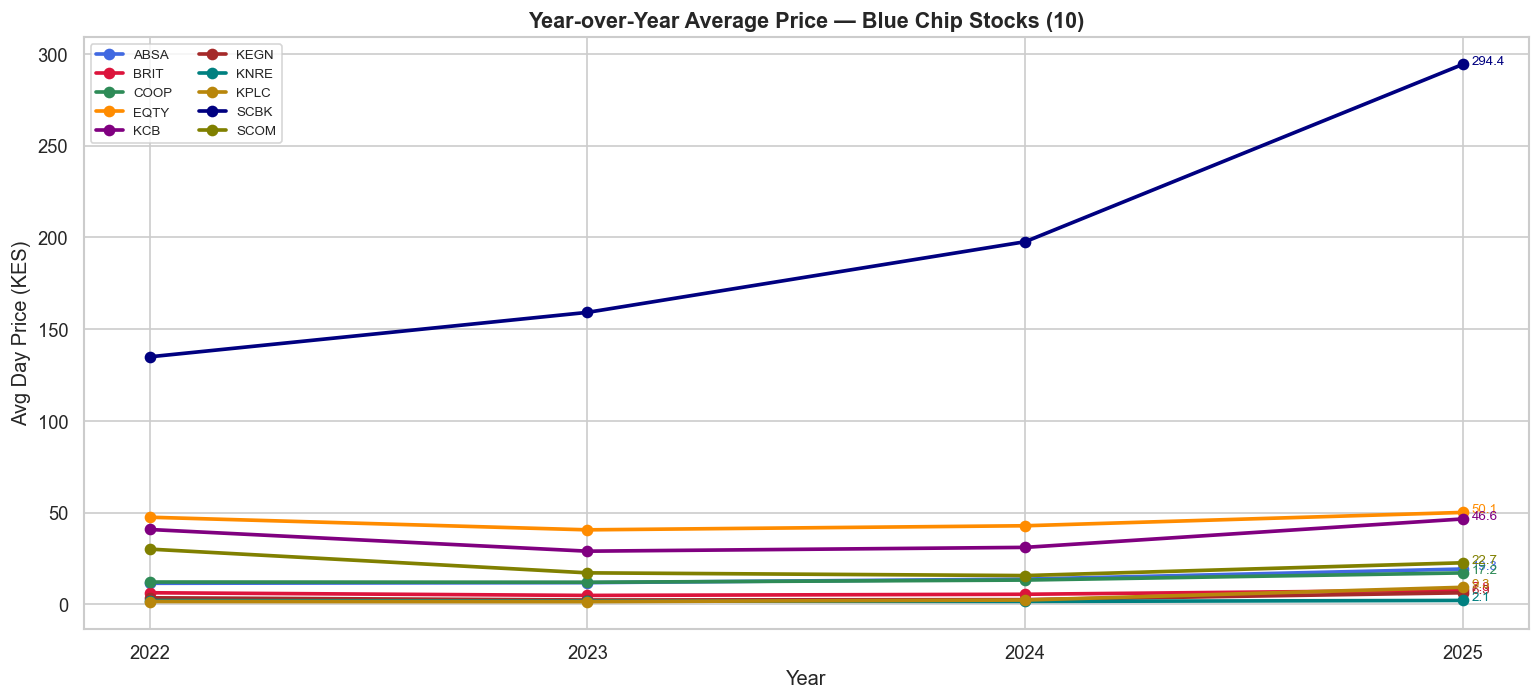


Yearly Average Prices (KES):
year    2022    2023    2024    2025
code                                
ABSA   11.49   11.84   13.77   19.27
BRIT    6.33    4.88    5.52    7.76
COOP   12.19   12.06   13.26   17.16
EQTY   47.50   40.63   42.85   50.13
KCB    40.82   29.00   31.07   46.57
KEGN    3.59    2.40    2.58    6.32
KNRE    2.08    1.81    1.62    2.15
KPLC    1.57    1.50    2.36    9.31
SCBK  134.93  159.16  197.68  294.41
SCOM   30.12   17.18   15.70   22.68


In [215]:
yearly_avg = (nse_data[nse_data['code'].isin(blue_chips)]
              .groupby(['code', 'year'])['day_price']
              .mean()
              .unstack())

fig, ax = plt.subplots(figsize=(13, 6))
for code, color in zip(yearly_avg.index, colors_bc):
    ax.plot(yearly_avg.columns.astype(str), yearly_avg.loc[code],
            marker='o', lw=2.2, label=code, color=color)
    ax.annotate(
        f'{yearly_avg.loc[code].iloc[-1]:.1f}',
        xy=(str(yearly_avg.columns[-1]), yearly_avg.loc[code].iloc[-1]),
        xytext=(5, 0), textcoords='offset points', fontsize=8, color=color
    )
ax.set_title('Year-over-Year Average Price — Blue Chip Stocks (10)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Day Price (KES)')
ax.set_xlabel('Year')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

print('\nYearly Average Prices (KES):')
print(yearly_avg.round(2))


### 4.7 Correlation Matrix

The most important finding: `day_price` correlates with `previous` at **0.999**. Yesterday's closing price is already a near-perfect predictor of today's price. This means any model must beat a simple 'predict tomorrow = today' strategy to add real value. `volume` and `changepct` show near-zero correlation with `day_price`, confirming that raw volume alone does not predict price level.

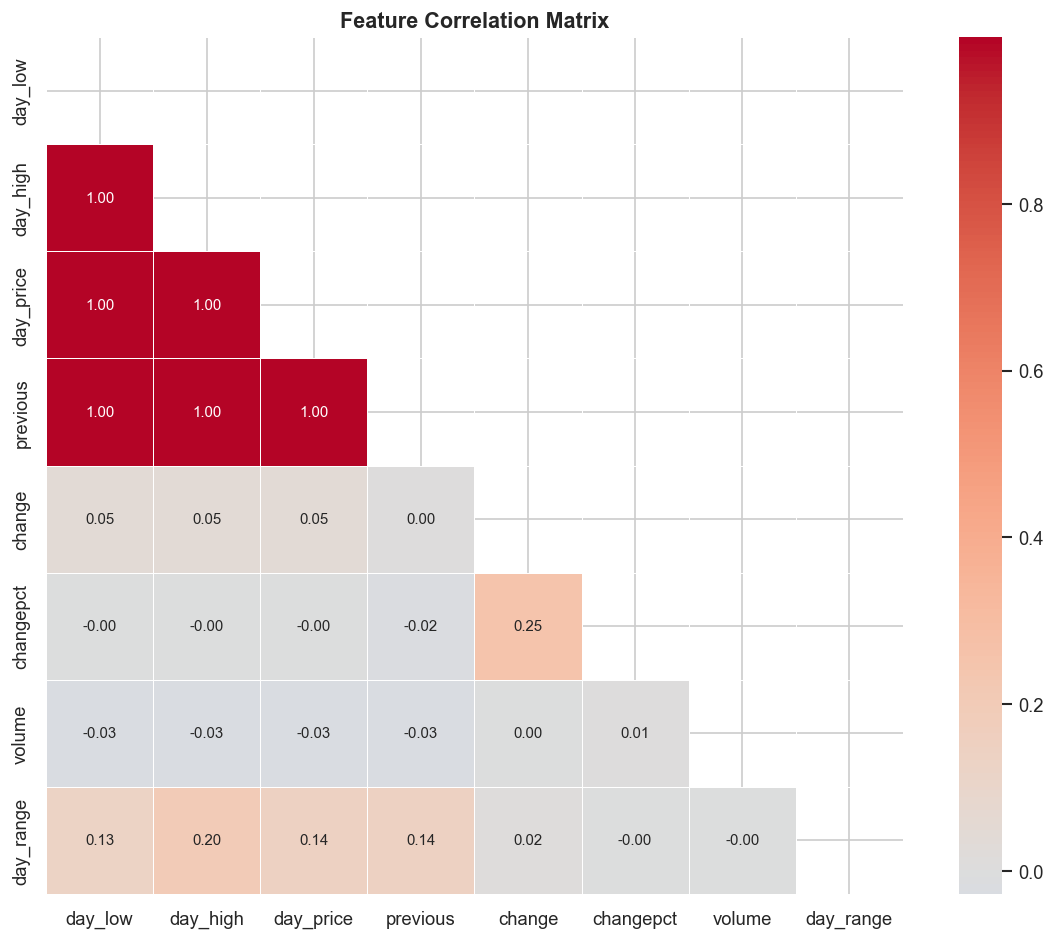


Key correlations with day_price:
day_low      1.000
previous     0.999
day_high     0.998
day_range    0.142
change       0.048
changepct   -0.005
volume      -0.027
Name: day_price, dtype: float64


In [216]:
corr_cols = ['day_low','day_high','day_price','previous',
             'change','changepct','volume','day_range']
corr = nse_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey correlations with day_price:')
print(corr['day_price'].drop('day_price').sort_values(ascending=False).round(3))

### 4.8 Volume Analysis: Zero-Volume Days and Distribution

Nearly 30% of all trading days across the full NSE dataset had zero volume, meaning no shares changed hands. This is a characteristic of the Kenyan market, not a data error. Focusing on blue chips significantly reduces this problem.

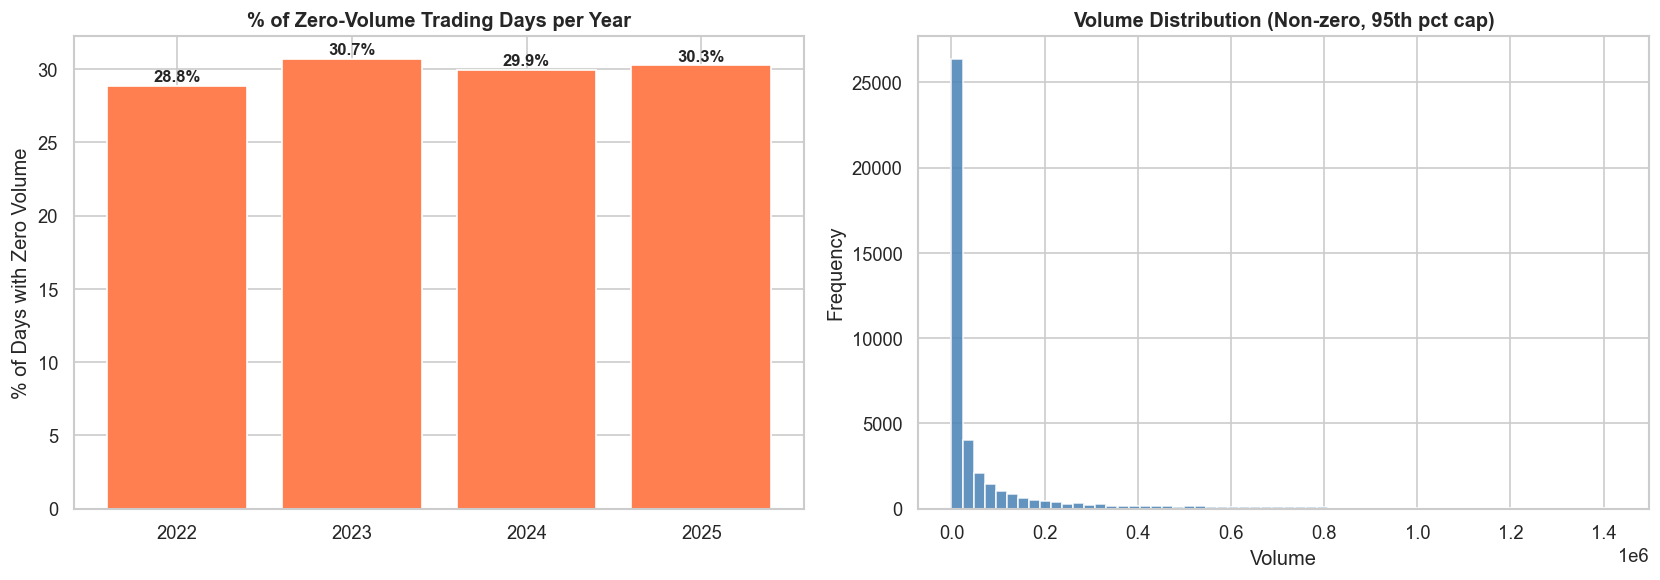

Total zero-volume records : 18,878 (29.9%)
Total non-zero records    : 44,181

Volume stats (non-zero):
count        44181.0
mean        374115.0
std        2512570.0
min              1.0
25%           1700.0
50%          11700.0
75%          81600.0
max      208485900.0
Name: volume, dtype: float64


In [217]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#  Zero volume days per year 
zero_by_year = nse_data.groupby('year').apply(
    lambda x: (x['volume'] == 0).mean() * 100
)
axes[0].bar(zero_by_year.index.astype(str), zero_by_year.values,
            color='coral', edgecolor='white')
axes[0].set_title('% of Zero-Volume Trading Days per Year',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('% of Days with Zero Volume')
for i, v in enumerate(zero_by_year.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Volume distribution (non-zero only, capped at 95th pct) 
vol_nz  = nse_data[nse_data['volume'] > 0]['volume']
cap_v   = vol_nz.quantile(0.95)
axes[1].hist(vol_nz[vol_nz <= cap_v], bins=60, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[1].set_title('Volume Distribution (Non-zero, 95th pct cap)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Volume')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

total_zero = (nse_data['volume'] == 0).sum()
print(f'Total zero-volume records : {total_zero:,} ({total_zero/len(nse_data)*100:.1f}%)')
print(f'Total non-zero records    : {(nse_data["volume"]>0).sum():,}')
print(f'\nVolume stats (non-zero):')
print(vol_nz.describe().round(0))

### 4.9 Intraday Range Analysis

We examine which stocks have the widest intraday high-low spread. Stocks with a wider daily range offer more opportunity for limit order placement, but also carry more risk of the price moving far from the prediction.

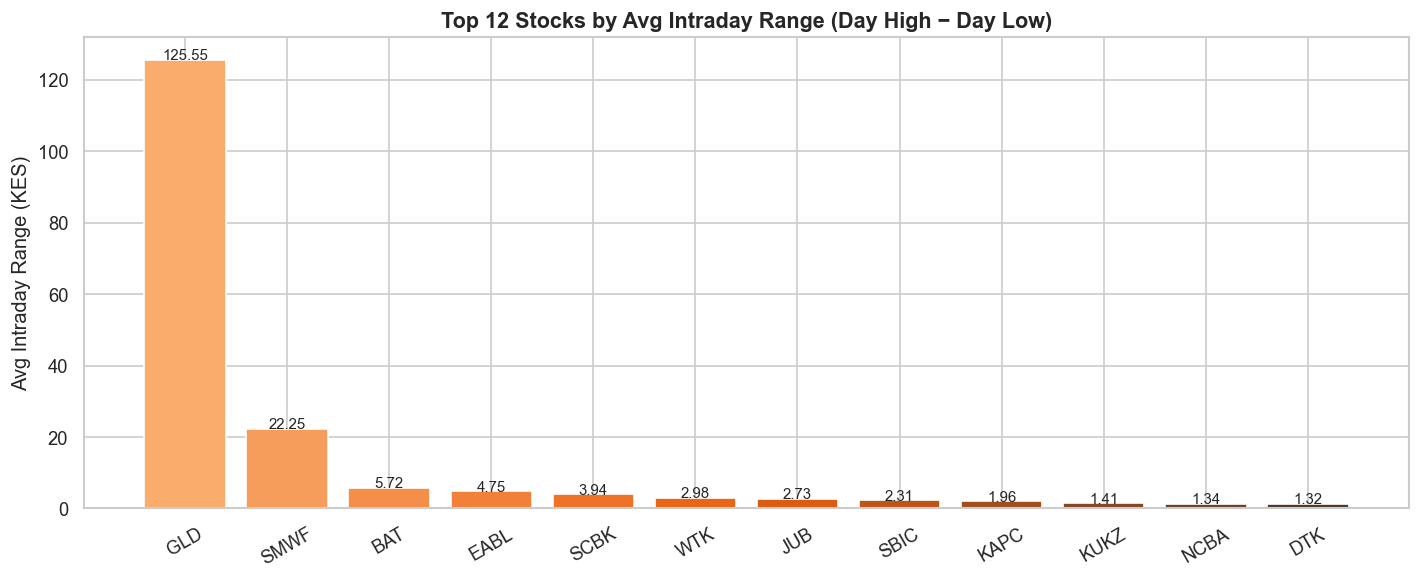


Top 10 by Relative Intraday Range (% of price):
        Range %
code           
HFCK-R   55.688
UCHM      7.131
HAFR      7.001
EVRD      6.621
SMER      5.873
CABL      5.741
HFCK      5.655
BRIT      5.478
CIC       5.236
KPLC      5.080


In [218]:
top_range = (nse_data.groupby('code')['day_range']
             .mean()
             .sort_values(ascending=False)
             .head(12))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_range.index, top_range.values,
       color=sns.color_palette('Oranges_d', 12), edgecolor='white')
ax.set_title('Top 12 Stocks by Avg Intraday Range (Day High − Day Low)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Intraday Range (KES)')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(top_range.values):
    ax.text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Also show as % of price (relative range)
avg_price = nse_data.groupby('code')['day_price'].mean()
rel_range = (nse_data.groupby('code')['day_range'].mean() / avg_price * 100).dropna()
print('\nTop 10 by Relative Intraday Range (% of price):')
print(rel_range.sort_values(ascending=False).head(10).round(3).rename('Range %').to_frame())

### 4.10 Return Distributions for Blue Chip Stocks

All blue chip stocks show kurtosis well above 3, meaning extreme daily moves happen more often than a normal distribution would predict. This is relevant for setting expectations about forecast errors (on most days the model will be close, but rare extreme days will produce larger errors).

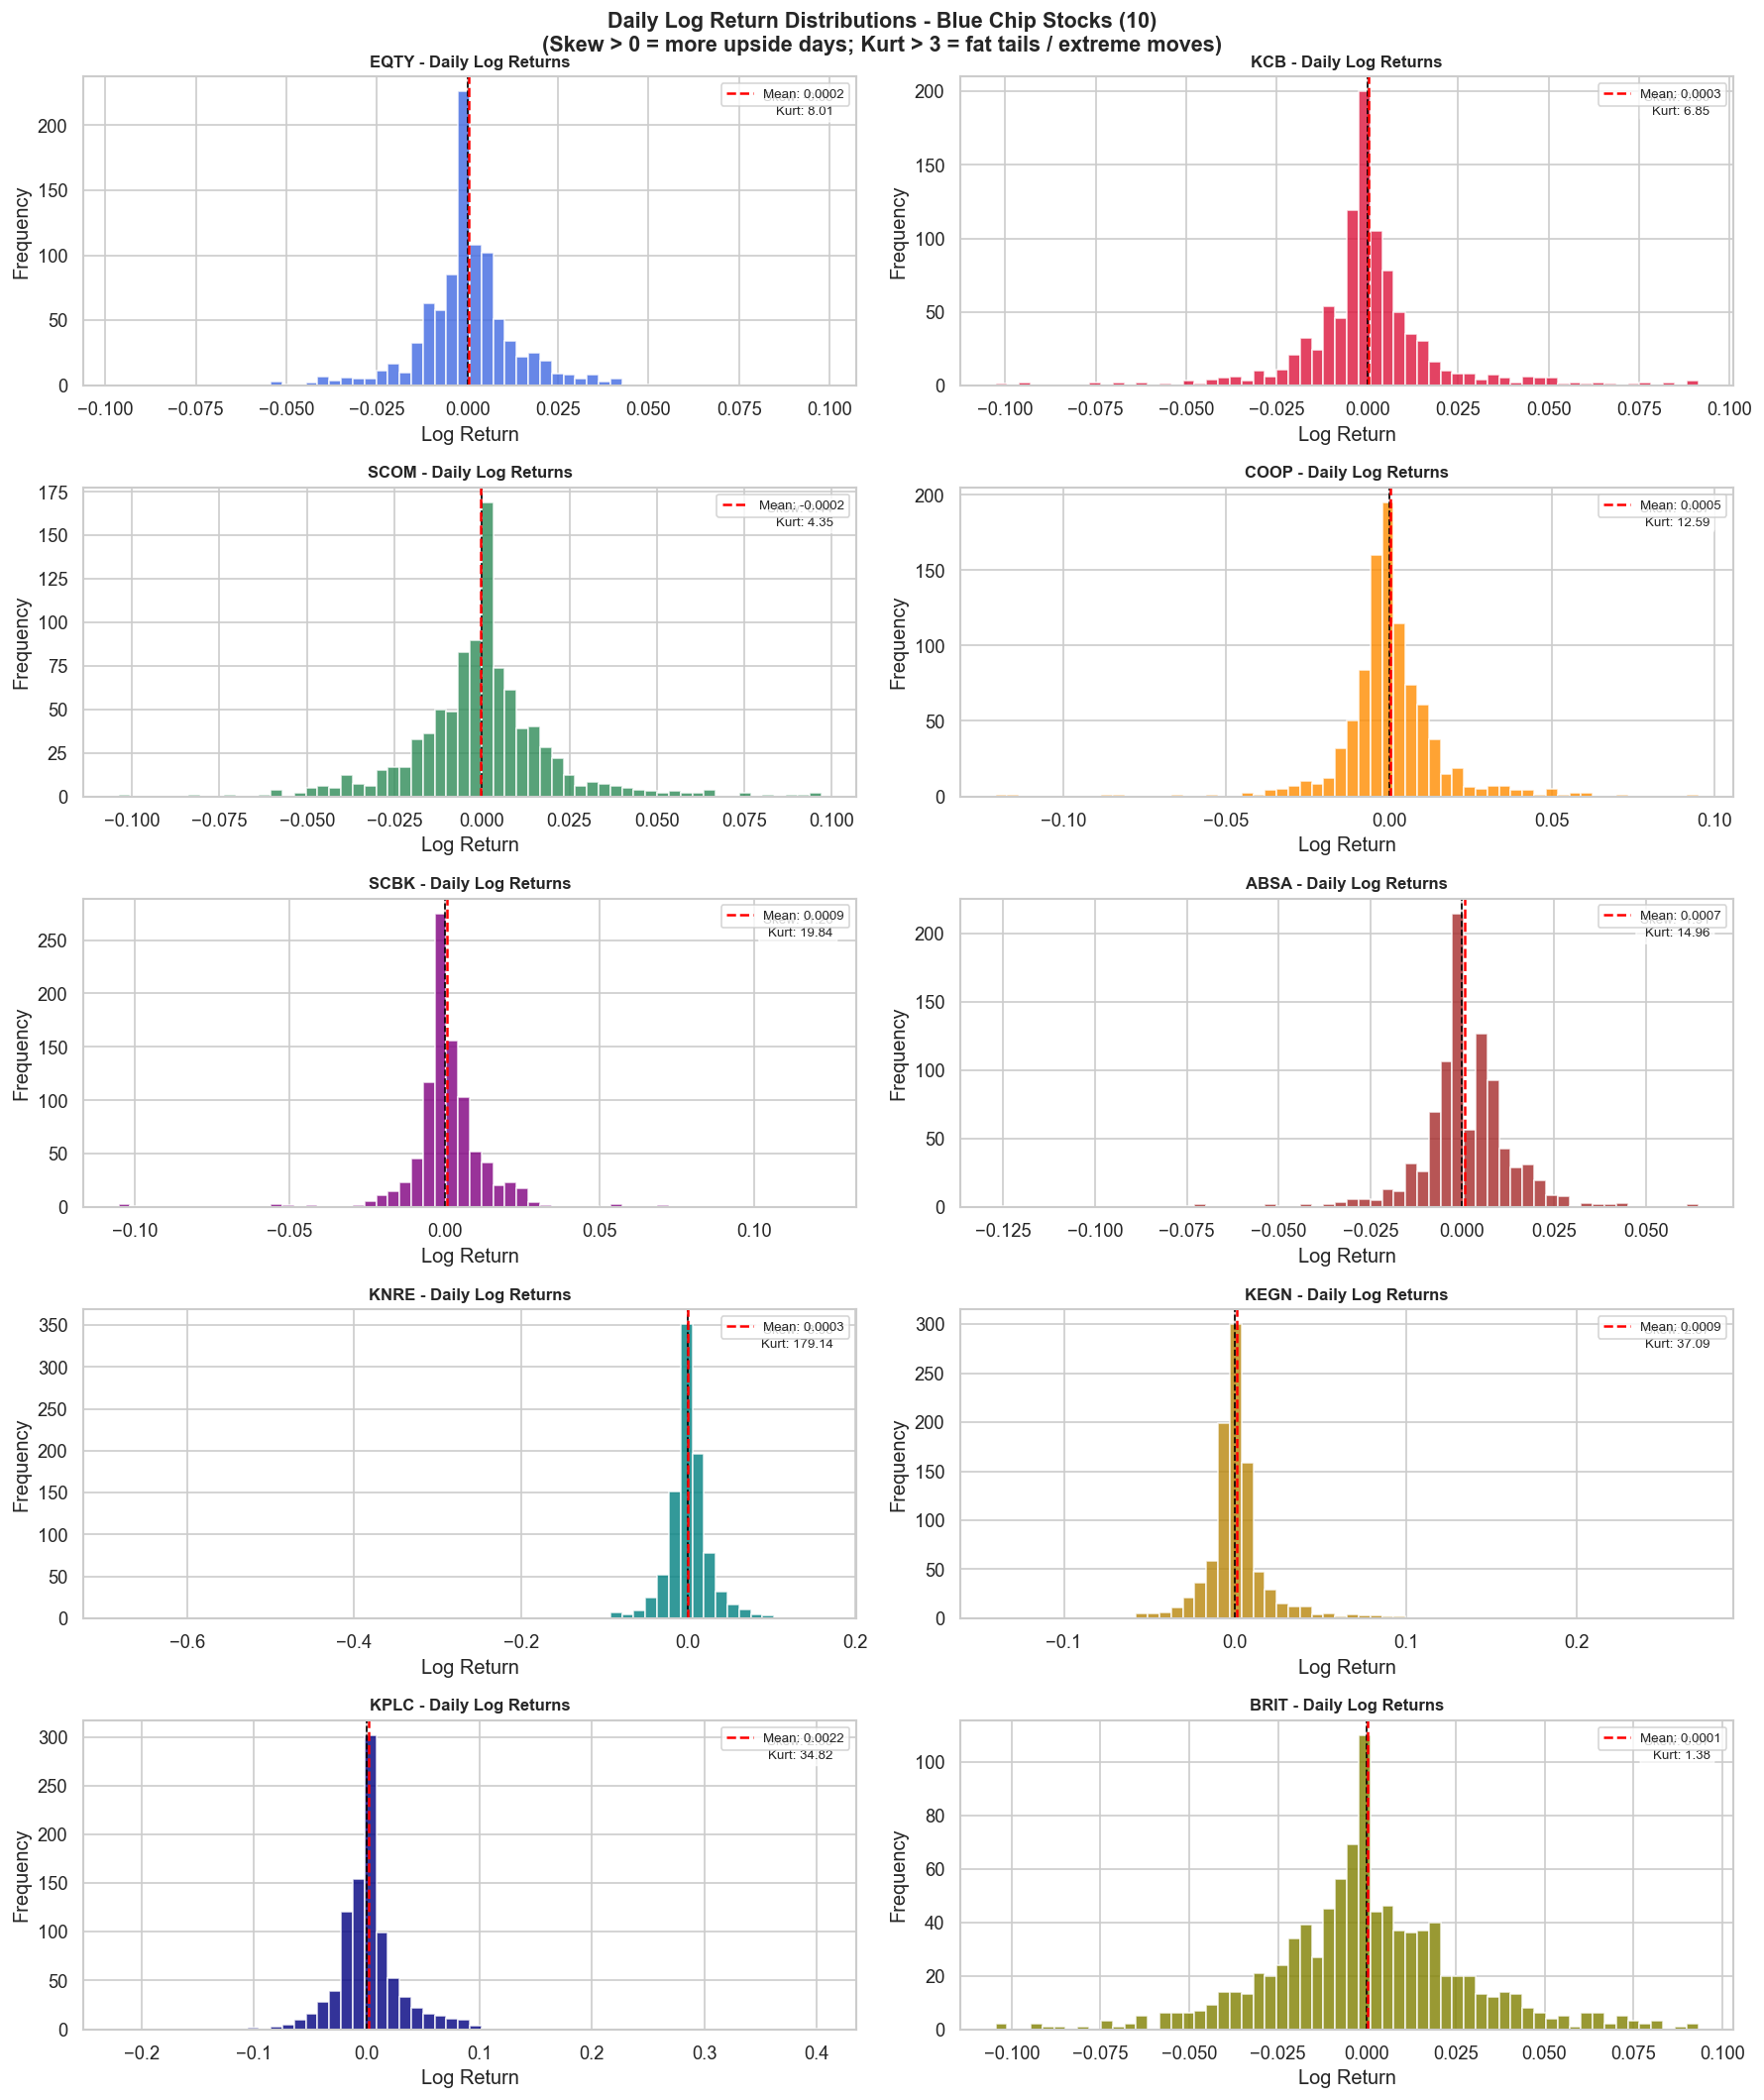

Return Statistics Summary:
       Mean Return  Std (Vol)  Skewness  Kurtosis  Max Gain%  Max Loss%
Stock                                                                  
EQTY       0.00024    0.01479    -0.083     8.009       9.76      -9.63
KCB        0.00032    0.01865     0.301     6.854       9.13     -10.26
SCOM      -0.00025    0.01995     0.436     4.354       9.69     -10.38
COOP       0.00051    0.01537    -0.567    12.591       9.50     -12.09
SCBK       0.00090    0.01483    -1.262    19.840      12.17     -10.54
ABSA       0.00071    0.01449    -1.914    14.956       6.43     -12.71
KNRE       0.00029    0.03385    -8.979   179.138      15.96     -68.26
KEGN       0.00095    0.02050     2.867    37.089      27.09     -14.00
KPLC       0.00219    0.03058     2.352    34.823      40.36     -22.03
BRIT       0.00014    0.02731     0.072     1.381       9.32     -10.45


In [219]:
fig, axes = plt.subplots(5, 2, figsize=(15, 18))
axes      = axes.flatten()

for i, (code, color) in enumerate(zip(blue_chips, colors_bc)):
    sub = nse_data[nse_data['code'] == code]['log_return'].dropna()
    if sub.empty:
        axes[i].set_visible(False)
        continue
    axes[i].hist(sub, bins=60, color=color, edgecolor='white', alpha=0.8)
    axes[i].axvline(0,          color='black', lw=1,   linestyle='--')
    axes[i].axvline(sub.mean(), color='red',   lw=1.5, linestyle='--',
                    label=f'Mean: {sub.mean():.4f}')
    axes[i].set_title(f'{code} - Daily Log Returns', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Log Return')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)
    axes[i].text(
        0.97, 0.95,
        f'Skew: {sub.skew():.2f}\nKurt: {sub.kurt():.2f}',
        transform=axes[i].transAxes, ha='right', va='top', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )

fig.suptitle('Daily Log Return Distributions - Blue Chip Stocks (10)\n'
             '(Skew > 0 = more upside days; Kurt > 3 = fat tails / extreme moves)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Return Statistics Summary:')
stats = []
for code in blue_chips:
    sub = nse_data[nse_data['code'] == code]['log_return'].dropna()
    if sub.empty:
        continue
    stats.append({
        'Stock':        code,
        'Mean Return':  round(sub.mean(), 5),
        'Std (Vol)':    round(sub.std(),  5),
        'Skewness':     round(sub.skew(), 3),
        'Kurtosis':     round(sub.kurt(), 3),
        'Max Gain%':    round(sub.max() * 100, 2),
        'Max Loss%':    round(sub.min() * 100, 2),
    })
print(pd.DataFrame(stats).set_index('Stock').to_string())


## 5. Feature Engineering

All features are constructed from **past data only**. Every lag and rolling calculation uses `.shift(1)` so today's model input never includes today's outcome. This prevents data leakage which is common in financial ML models.

We restrict to 10 blue-chip stocks selected for their liquidity, data completeness, and direct relevance to retail investors.

### 5.1 Lag Features

We use lag features because our EDA showed day-to-day price autocorrelation of 0.999. Lag features give the model yesterday's price, two days ago, and three days ago so it can detect short-term momentum. We apply lags to price and volume.

In [220]:
# Sort by stock and date first
nse_data = nse_data[nse_data['code'].isin(blue_chips)].copy()

#  Lag features 
# "What was the price yesterday, two days ago, three days ago?"
# .shift(1) per stock means we never use today's value to predict tomorrow

nse_data['price_lag1'] = nse_data.groupby('code')['day_price'].shift(1)
nse_data['price_lag2'] = nse_data.groupby('code')['day_price'].shift(2)
nse_data['price_lag3'] = nse_data.groupby('code')['day_price'].shift(3)

nse_data['volume_lag1'] = nse_data.groupby('code')['volume'].shift(1)

### 5.2 Rolling Mean Features

Since individual daily prices are noisy, a 5-day and 20-day rolling average smooths that noise and reveals the underlying short and medium-term trend the model can learn from.

In [221]:
# Rolling means and std 
# What has the average price been over the last 5 / 20 trading days?
# .shift(1) before .rolling() ensures we don't include today

nse_data['price_roll5_mean']  = nse_data.groupby('code')['day_price'].transform(
    lambda x: x.shift(1).rolling(5).mean()
)
nse_data['price_roll20_mean'] = nse_data.groupby('code')['day_price'].transform(
    lambda x: x.shift(1).rolling(20).mean()
)
nse_data['price_roll5_std']   = nse_data.groupby('code')['day_price'].transform(
    lambda x: x.shift(1).rolling(5).std()
)

### 5.3 Exponentially Weighted Mean (EWM)

EWM serves the same purpose as rolling mean but gives more weight to recent days, making it more responsive to sudden price changes than a simple average.

In [ ]:
# EWM span=5 reacts fast to recent moves; span=20 is slower-moving
nse_data['price_ewm5']  = nse_data.groupby('code')['day_price'].transform(
    lambda x: x.shift(1).ewm(span=5).mean()
)
nse_data['price_ewm20'] = nse_data.groupby('code')['day_price'].transform(
    lambda x: x.shift(1).ewm(span=20).mean()
)

### 5.4 52-Week Relative Position

This feature shows where today's price sits within its annual high-low range. 

- 0 = at the yearly low
- 1 = at the yearly high

A stock near its annual high behaves differently from one near its annual low. Helps the model understand whether the stock is stretched or depressed.

In [ ]:
# 52-week position: 0 = at 12-month low, 1 = at 12-month high
nse_data['price_pos_52w'] = (
    (nse_data['day_price'] - nse_data['12m_low']) /
    (nse_data['12m_high'] - nse_data['12m_low'] + 1e-6)
)

### 5.5 Volume Ratio

Unusual trading activity often comes before a price move. We compare yesterday's volume to the 20-day average volume to flag abnormal activity.

In [ ]:
# Volume ratio: today's volume vs recent average
# Values above 1 = unusually high activity
nse_data['volume_ratio'] = nse_data['volume'] / (nse_data['price_roll20_mean'] + 1e-6)


### 5.6 Day of Week

Markets may behave differently by weekday; for example, Monday open effects or Friday close patterns. Encoding as a number (Monday=0, Friday=4) lets the model learn any such patterns.

In [ ]:
# Monday=0, Friday=4. Markets behave slightly differently by weekday
nse_data['dow_num'] = nse_data['date'].dt.dayofweek

### 5.7 Target Variable

`next_day_price` - tomorrow's actual closing price, created by shifting each stock's price series one row forward. 

In [227]:
# Create targets
# What we want to predict: the NEXT day's price
# .shift(-1) moves tomorrow's value into today's row
nse_data['next_day_price'] = nse_data.groupby('code')['day_price'].shift(-1)


### 5.8 Drop Rows with Missing Targets or Lags

The last row per stock has no next-day target (there is no tomorrow to predict). The first few rows per stock have no lag history yet. Both are dropped.

In [ ]:
# Drop rows with missing targets or missing lag1 
nse_data = nse_data.dropna(subset=[
    'next_day_price', 'price_lag1'
]).reset_index(drop=True)


In [229]:
print(f'Shape after feature engineering: {nse_data.shape}')
print(f'Date range: {nse_data["date"].min().date()} to {nse_data["date"].max().date()}')

Shape after feature engineering: (9433, 30)
Date range: 2022-01-04 to 2025-10-30


## 6. Modelling

### 6.1 Walk-Forward Split

Stock data is sequential. Splitting randomly would let the model train on future data to predict the past — this is called data leakage and produces artificially good metrics.

We use a strict time-based split:
- **Train:** 2022–2023 - what the model learns from
- **Validation:** 2024 - used to compare and tune models
- **Test:** 2025 - touched once at the very end, after all decisions are locked

In [230]:
TRAIN_END = '2023-12-31'
VAL_END   = '2024-12-31'

train = nse_data[nse_data['date'] <= TRAIN_END].copy()
val   = nse_data[(nse_data['date'] > TRAIN_END) & (nse_data['date'] <= VAL_END)].copy()
test  = nse_data[nse_data['date'] > VAL_END].copy()

print(f'Train : {train["date"].min().date()} - {train["date"].max().date()}  ({len(train):,} rows)')
print(f'Val   : {val["date"].min().date()} - {val["date"].max().date()}  ({len(val):,} rows)')
print(f'Test  : {test["date"].min().date()} - {test["date"].max().date()}  ({len(test):,} rows)')

Train : 2022-01-04 - 2023-12-29  (4,873 rows)
Val   : 2024-01-02 - 2024-12-31  (2,490 rows)
Test  : 2025-01-02 - 2025-10-30  (2,070 rows)


### 6.2 Evaluation Metric Setup

We use three metrics:
- **MAE** - average KES error. Directly interpretable: 'on average, the forecast is off by X shillings.'
- **RMSE** - penalises large errors more than MAE. If RMSE > MAE, the model occasionally makes very bad forecasts.
- **MAPE** - percentage error, useful for comparing across stocks at different price levels (SCOM at KES 15 vs SCBK at KES 294).

In [231]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# predicting Day Price only
TARGETS      = ['day_price']
TARGET_LABELS = {'day_price': 'Day Price'}

results = {}

def evaluate(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-6))) * 100
    if label:
        print(f'  {label:<30} MAE={mae:>8.4f}  RMSE={rmse:>8.4f}  MAPE={mape:>6.2f}%')
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

### 6.3 Baseline 1 - Persistence

**What it is:** Predicts tomorrow price = today's closing price. 

With autocorrelation of 0.999, this is the hardest baseline to beat in financial forecasting. If any model cannot beat this, it has learned nothing useful beyond what is already obvious.

In [232]:
results['Persistence'] = {}

# Persistence for day_price: tomorrow = today's price
persistence_map = {'day_price': 'price_lag1'}

print('BASELINE 1: PERSISTENCE \n')

mask    = val['price_lag1'].notna()
metrics = evaluate(
    val.loc[mask, 'next_day_price'],
    val.loc[mask, 'price_lag1'],
    label='Day Price'
)
results['Persistence']['day_price'] = metrics

BASELINE 1: PERSISTENCE 

  Day Price                      MAE=  0.5112  RMSE=  1.4273  MAPE=  2.13%


### 6.4 Baseline 2 - Rolling Mean and EWM

**What it is:** Predict tomorrow using the 5-day rolling average and EWM of price.

These smoothing baselines, test whether incorporating recent trend information helps, or whether smoothing actually destroys the signal (which it does, confirming persistence is the stronger baseline)

In [233]:
results['Rolling5'] = {}
results['EWM5']     = {}

print('BASELINE 2: ROLLING MEAN & EWM \n')

mask = val['price_roll5_mean'].notna() & val['price_ewm5'].notna()

r_metrics = evaluate(val.loc[mask, 'next_day_price'],
                     val.loc[mask, 'price_roll5_mean'],
                     label='Rolling 5-day Mean')

e_metrics = evaluate(val.loc[mask, 'next_day_price'],
                     val.loc[mask, 'price_ewm5'],
                     label='EWM span=5')

results['Rolling5']['day_price'] = r_metrics
results['EWM5']['day_price']     = e_metrics

BASELINE 2: ROLLING MEAN & EWM 

  Rolling 5-day Mean             MAE=  0.7122  RMSE=  1.9298  MAPE=  2.82%
  EWM span=5                     MAE=  0.6732  RMSE=  1.8391  MAPE=  2.65%


### 6.5 Baseline Visualisation

Visual check: how closely do persistence and EWM track actual next-day prices for EQTY?

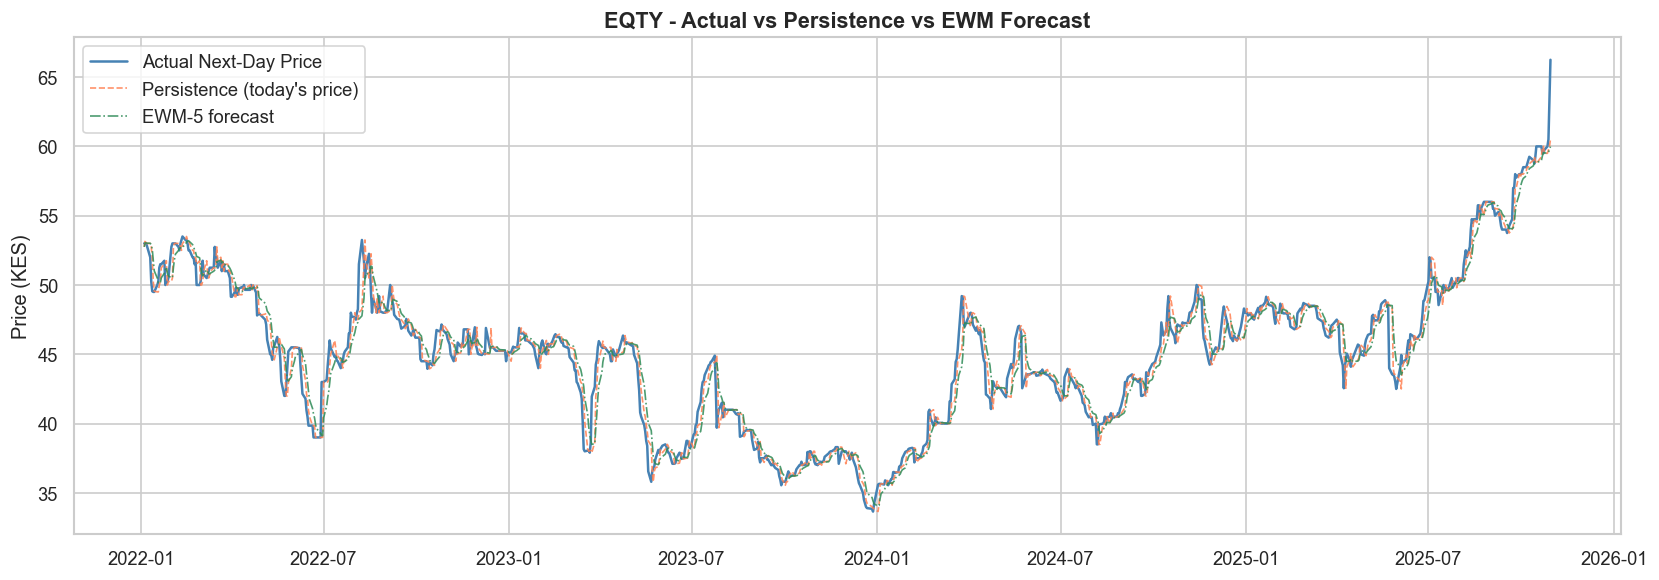

In [234]:
import matplotlib.pyplot as plt

stock = 'EQTY'
sub   = nse_data[nse_data['code'] == stock].copy()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(sub['date'], sub['next_day_price'],  label='Actual Next-Day Price',
        color='steelblue', lw=1.5)
ax.plot(sub['date'], sub['price_lag1'],      label='Persistence (today\'s price)',
        color='coral', lw=1, linestyle='--', alpha=0.85)
ax.plot(sub['date'], sub['price_ewm5'],      label='EWM-5 forecast',
        color='seagreen', lw=1, linestyle='-.', alpha=0.85)

ax.set_title(f'{stock} - Actual vs Persistence vs EWM Forecast', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (KES)')
ax.legend()
plt.tight_layout()
plt.show()

### 6.6 Model 1 - Ridge Regression

**What it is:** Linear regression with L2 regularisation on all engineered features.

Ridge tests whether there is any linear signal in the engineered features beyond persistence. The L2 penalty (alpha=100) is necessary because price_lag1 and the rolling/EWM features are highly correlated. A plain OLS would produce unstable, inflated coefficients.

**Expected improvement:** If Ridge beats persistence, there is learnable linear signal. If not, we need nonlinear models.

In [235]:
from sklearn.linear_model import Ridge

FEATURE_COLS = [
    'price_lag1', 'price_lag2', 'price_lag3',
    'low_lag1',   'low_lag2',
    'high_lag1',  'high_lag2',
    'volume_lag1',
    'price_roll5_mean', 'price_roll20_mean',
    'price_roll5_std',
    'price_ewm5', 'price_ewm20',
    'price_pos_52w',
    'volume_ratio',
    'dow_num',
    'range_lag1',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in nse_data.columns]

print('MODEL 1: RIDGE REGRESSION - Day Price only \n')

results['RidgeRegression'] = {}

train_clean = train[FEATURE_COLS + ['next_day_price']].dropna()
val_clean   = val[FEATURE_COLS + ['next_day_price']].dropna()

X_train = train_clean[FEATURE_COLS]
y_train = train_clean['next_day_price']
X_val   = val_clean[FEATURE_COLS]
y_val   = val_clean['next_day_price']

lr_model = Ridge(alpha=100.0)
lr_model.fit(X_train, y_train)
y_pred   = lr_model.predict(X_val)

metrics = evaluate(y_val, y_pred, label='Day Price')
results['RidgeRegression']['day_price'] = metrics

# Coefficients
coef_df = pd.DataFrame({
    'Feature':     FEATURE_COLS,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('\nTop 10 features by absolute coefficient:')
print(coef_df.head(10).to_string(index=False))

MODEL 1: RIDGE REGRESSION - Day Price only 

  Day Price                      MAE=  0.5217  RMSE=  1.4204  MAPE=  2.44%

Top 10 features by absolute coefficient:
          Feature  Coefficient
       price_lag1     1.056582
      price_ewm20     0.185687
price_roll20_mean    -0.141239
    price_pos_52w    -0.077871
       price_lag2    -0.075380
  price_roll5_std     0.040314
       price_ewm5    -0.026092
       price_lag3     0.012386
 price_roll5_mean    -0.011718
          dow_num    -0.011609


**Ridge Regression Result:**

Ridge does not meaningfully improve on persistence. The dominant coefficient (price_lag1) confirms the model is anchoring on yesterday's price. The negative coefficients on rolling mean features suggest a weak mean-reversion signal that does not translate into a measurable improvement.

**Conclusion:** The price prediction problem is not purely linear. We proceed to evaluate the model on the test set.